MEAN NIR SPECTRUM PLOT

1. Loading NIR data...
NIR shape: (144, 2152)
Samples: 144
Wavelengths/variables: 2151

2. Calculating mean spectrum and standard deviation...
✅ Calculations complete

3. Generating mean spectrum plot...
✅ Plot saved: spectrum_plots/mean_nir_spectrum.png


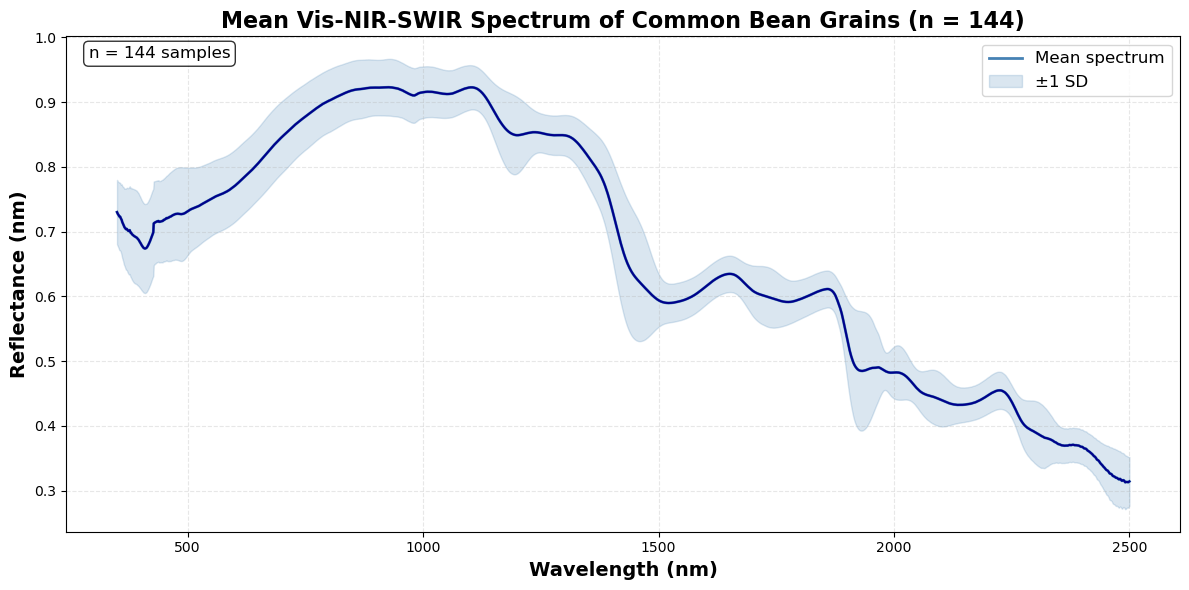


4. Generating overlay plot (individual + mean)...
✅ Plot saved: spectrum_plots/individual_mean_spectrum.png


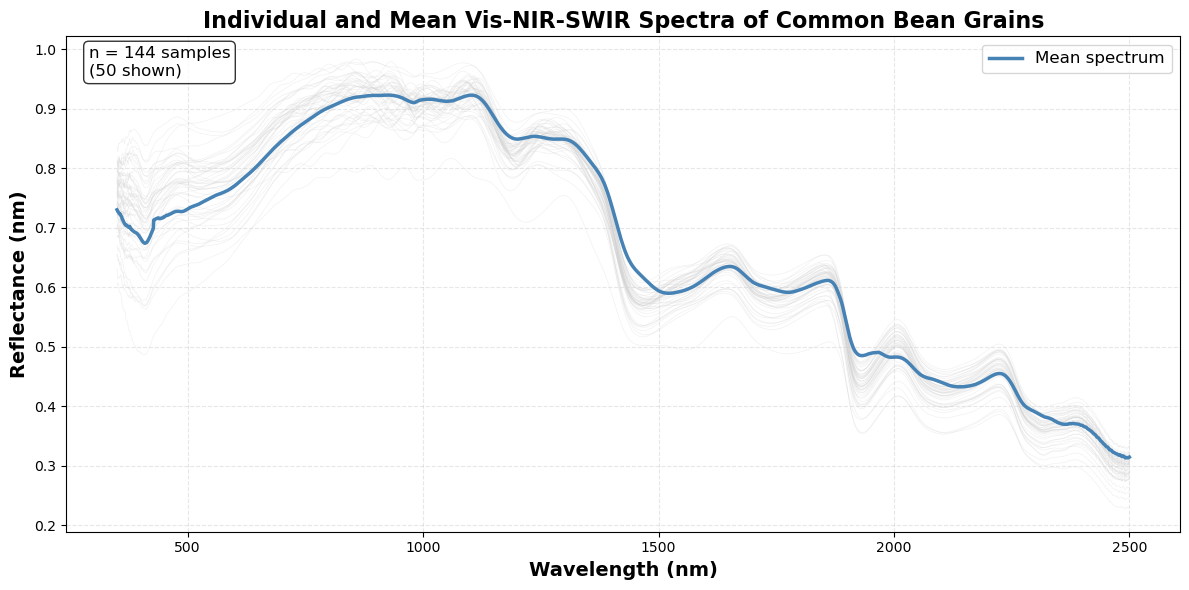


5. Saving spectrum statistics...
✅ Statistics saved: spectrum_plots/spectrum_statistics.csv

PLOT GENERATION COMPLETED

Files created:
  - spectrum_plots/mean_nir_spectrum.png (mean ± SD)
  - spectrum_plots/individual_mean_spectrum.png (individual + mean)
  - spectrum_plots/spectrum_statistics.csv (summary statistics)


In [4]:
# ====================================================
# MEAN NIR SPECTRUM PLOT - Common Bean Samples
# ====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set working directory
base_path = "D:/Marcelo_Posdoc/PosDocFAPESP/Miscelaneous_PosDoc/Art_Marcelo&Filipe"
os.chdir(base_path)

# Create output folder
output_folder = "spectrum_plots"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

print("="*50)
print("MEAN NIR SPECTRUM PLOT")
print("="*50)

# 1. LOAD NIR DATA
# ----------------------------------------------------
print("\n1. Loading NIR data...")
nir_data = pd.read_csv("nir.csv", sep=';')
print(f"NIR shape: {nir_data.shape}")

# Extract ID column and spectra
id_col = nir_data.columns[0]
nir_spectra = nir_data.drop(columns=[id_col]).values
nir_cols = nir_data.columns[1:]

print(f"Samples: {nir_spectra.shape[0]}")
print(f"Wavelengths/variables: {nir_spectra.shape[1]}")

# 2. CALCULATE MEAN AND STANDARD DEVIATION
# ----------------------------------------------------
print("\n2. Calculating mean spectrum and standard deviation...")

mean_spectrum = np.mean(nir_spectra, axis=0)
std_spectrum = np.std(nir_spectra, axis=0)
sem_spectrum = std_spectrum / np.sqrt(nir_spectra.shape[0])  # Standard Error of the Mean

# Try to convert wavelengths to numeric
try:
    wavelengths = np.array([float(col) for col in nir_cols])
    xlabel = 'Wavelength (nm)'
except:
    wavelengths = np.arange(len(nir_cols))
    xlabel = 'Variable Index'

print("✅ Calculations complete")

# 3. CREATE THE PLOT
# ----------------------------------------------------
print("\n3. Generating mean spectrum plot...")

# Set style
plt.style.use('default')
sns.set_palette("husl")

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot mean spectrum with confidence band
ax.plot(wavelengths, mean_spectrum, 
        color='steelblue', linewidth=2, label='Mean spectrum')
ax.fill_between(wavelengths, 
                mean_spectrum - std_spectrum, 
                mean_spectrum + std_spectrum,
                color='steelblue', alpha=0.2, label='±1 SD')

# Add mean line slightly thicker
ax.plot(wavelengths, mean_spectrum, 
        color='darkblue', linewidth=1.5)

# Labels and title
ax.set_xlabel(xlabel, fontsize=14, fontweight='bold')
ax.set_ylabel('Reflectance (nm)', fontsize=14, fontweight='bold')
ax.set_title('Mean Vis-NIR-SWIR Spectrum of Common Bean Grains (n = 144)', 
             fontsize=16, fontweight='bold')

# Customize grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add legend
ax.legend(loc='upper right', fontsize=12)

# Add sample size annotation
ax.text(0.02, 0.98, f'n = {nir_spectra.shape[0]} samples', 
        transform=ax.transAxes, fontsize=12,
        verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Adjust layout
plt.tight_layout()

# Save the plot
plt.savefig(f"{output_folder}/mean_nir_spectrum.png", dpi=300, bbox_inches='tight')
print(f"✅ Plot saved: {output_folder}/mean_nir_spectrum.png")

# Show the plot
plt.show()

# 4. OPTIONAL: INDIVIDUAL SPECTRA (light gray) + MEAN (color)
# ----------------------------------------------------
print("\n4. Generating overlay plot (individual + mean)...")

fig, ax = plt.subplots(figsize=(12, 6))

# Plot all individual spectra in light gray with low alpha
for i in range(min(50, nir_spectra.shape[0])):  # Plot up to 50 samples to avoid overplotting
    ax.plot(wavelengths, nir_spectra[i, :], 
            color='lightgray', alpha=0.3, linewidth=0.5)

# Plot mean spectrum in color
ax.plot(wavelengths, mean_spectrum, 
        color='steelblue', linewidth=2.5, label='Mean spectrum')

# Labels and title
ax.set_xlabel(xlabel, fontsize=14, fontweight='bold')
ax.set_ylabel('Reflectance (nm)', fontsize=14, fontweight='bold')
ax.set_title('Individual and Mean Vis-NIR-SWIR Spectra of Common Bean Grains', 
             fontsize=16, fontweight='bold')

# Customize grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add legend
ax.legend(loc='upper right', fontsize=12)

# Add sample size annotation
ax.text(0.02, 0.98, f'n = {nir_spectra.shape[0]} samples\n(50 shown)', 
        transform=ax.transAxes, fontsize=12,
        verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Adjust layout
plt.tight_layout()

# Save the plot
plt.savefig(f"{output_folder}/individual_mean_spectrum.png", dpi=500, bbox_inches='tight')
print(f"✅ Plot saved: {output_folder}/individual_mean_spectrum.png")

plt.show()

# 5. OPTIONAL: STATISTICS SUMMARY
# ----------------------------------------------------
print("\n5. Saving spectrum statistics...")

# Create summary statistics
spectrum_stats = pd.DataFrame({
    'Wavelength': wavelengths if 'wavelengths' in locals() else nir_cols,
    'Mean': mean_spectrum,
    'Std': std_spectrum,
    'SEM': sem_spectrum,
    'Min': np.min(nir_spectra, axis=0),
    'Max': np.max(nir_spectra, axis=0)
})

# Save to CSV
spectrum_stats.to_csv(f"{output_folder}/spectrum_statistics.csv", index=False)
print(f"✅ Statistics saved: {output_folder}/spectrum_statistics.csv")

print("\n" + "="*50)
print("PLOT GENERATION COMPLETED")
print("="*50)
print(f"\nFiles created:")
print(f"  - {output_folder}/mean_nir_spectrum.png (mean ± SD)")
print(f"  - {output_folder}/individual_mean_spectrum.png (individual + mean)")
print(f"  - {output_folder}/spectrum_statistics.csv (summary statistics)")